# Markowitz Efficient Frontier Portfolio Optimisation

## Objective

The objective of this notebook is to construct an optimal mutual fund portfolio using Modern Portfolio Theory (MPT).

The Markowitz Efficient Frontier identifies portfolios that provide:

- Maximum expected return for a given level of risk
- Minimum risk for a given expected return

The analysis is performed on five selected mutual fund schemes using historical NAV data.

Selected Funds:

1. SBI Bluechip Fund
2. ICICI Bluechip Fund
3. Nippon India Large Cap Fund
4. Axis Bluechip Fund
5. Kotak Bluechip Fund

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.optimize import minimize

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

## Load Historical NAV Data

In [2]:
nav = pd.read_csv("../data/processed/clean_02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


## Select Five Funds

In [3]:
selected_funds = [
    119551,  # SBI Bluechip
    120503,  # ICICI Bluechip
    118632,  # Nippon Large Cap
    119092,  # Axis Bluechip
    120841   # Kotak Bluechip
]

funds = nav[
    nav["amfi_code"].isin(selected_funds)
].copy()

funds.head()

,amfi_code,date,nav
10350,118632,2022-01-03,42.8339
10351,118632,2022-01-04,42.8033
10352,118632,2022-01-05,43.0564
10353,118632,2022-01-06,43.2088
10354,118632,2022-01-07,42.9585


## Create NAV Matrix

In [4]:
nav_matrix = funds.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

nav_matrix.head()

amfi_code,118632,119092,119551,120503,120841
date,,,,,
2022-01-03,42.8339,38.7466,54.3856,55.3983,275.8370
2022-01-04,42.8033,38.4924,54.3474,55.6327,276.8163
2022-01-05,43.0564,38.2033,54.6869,55.9527,276.3892
2022-01-06,43.2088,38.5825,55.4550,56.6067,278.9247
2022-01-07,42.9585,38.9425,55.3692,57.5741,281.1488


## Calculate Daily Returns

In [5]:
returns = nav_matrix.pct_change().dropna()

returns.head()

amfi_code,118632,119092,119551,120503,120841
date,,,,,
2022-01-04,-0.000714,-0.006561,-0.000702,0.004231,0.003550
2022-01-05,0.005913,-0.007511,0.006247,0.005752,-0.001543
2022-01-06,0.003540,0.009926,0.014045,0.011688,0.009174
2022-01-07,-0.005793,0.009331,-0.001547,0.017090,0.007974
2022-01-10,0.006360,-0.009961,-0.001548,0.001617,-0.021464


## Annualised Returns and Covariance Matrix

In [6]:
annual_returns = returns.mean() * 252

cov_matrix = returns.cov() * 252

annual_returns

amfi_code
118632     0.193313
119092    26.495627
119551     0.166797
120503     0.151647
120841     0.023530
dtype: float64

In [7]:
cov_matrix

amfi_code,118632,119092,119551,120503,120841
amfi_code,,,,,
118632,0.022790,-2.980929,0.006584,0.002761,0.011292
119092,-2.980929,3186.938940,-7.747374,-2.911318,-13.025464
119551,0.006584,-7.747374,0.037696,0.006799,0.031068
120503,0.002761,-2.911318,0.006799,0.021922,0.011414
120841,0.011292,-13.025464,0.031068,0.011414,0.071357


## Portfolio Return Function

In [8]:
def portfolio_return(weights):

    return np.sum(
        annual_returns * weights
    )

## Portfolio Risk Function

In [9]:
def portfolio_risk(weights):

    return np.sqrt(
        np.dot(
            weights.T,
            np.dot(cov_matrix, weights)
        )
    )

## Generate Random Portfolios

In [10]:
num_portfolios = 5000

results = np.zeros((3, num_portfolios))

weights_record = []

for i in range(num_portfolios):

    weights = np.random.random(
        len(selected_funds)
    )

    weights /= np.sum(weights)

    weights_record.append(weights)

    port_return = portfolio_return(weights)

    port_risk = portfolio_risk(weights)

    sharpe = port_return / port_risk

    results[0, i] = port_return
    results[1, i] = port_risk
    results[2, i] = sharpe

## Efficient Frontier Visualization

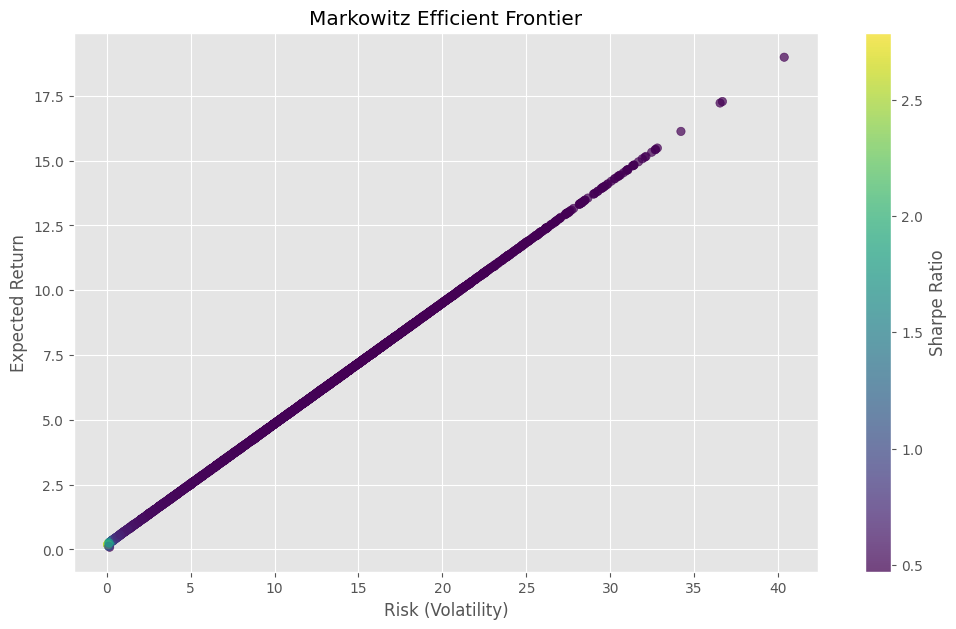

In [11]:
plt.figure(figsize=(12,7))

scatter = plt.scatter(
    results[1],
    results[0],
    c=results[2],
    cmap="viridis",
    alpha=0.7
)

plt.colorbar(
    scatter,
    label="Sharpe Ratio"
)

plt.xlabel("Risk (Volatility)")
plt.ylabel("Expected Return")

plt.title(
    "Markowitz Efficient Frontier"
)

plt.show()

## Identify Maximum Sharpe Portfolio

In [12]:
max_sharpe_idx = np.argmax(results[2])

optimal_weights = weights_record[
    max_sharpe_idx
]

optimal_return = results[0][max_sharpe_idx]
optimal_risk = results[1][max_sharpe_idx]
optimal_sharpe = results[2][max_sharpe_idx]

In [13]:
portfolio = pd.DataFrame({

    "Fund Code": selected_funds,

    "Weight (%)":
        optimal_weights * 100
})

portfolio

,Fund Code,Weight (%)
0,119551,21.973037
1,120503,0.220671
2,118632,32.799261
3,119092,17.571697
4,120841,27.435334


In [14]:
print("Optimal Portfolio")

print(
    f"Expected Return : {optimal_return:.2%}"
)

print(
    f"Risk : {optimal_risk:.2%}"
)

print(
    f"Sharpe Ratio : {optimal_sharpe:.2f}"
)

Optimal Portfolio
Expected Return : 18.88%
Risk : 6.77%
Sharpe Ratio : 2.79


## Visualise Portfolio Allocation

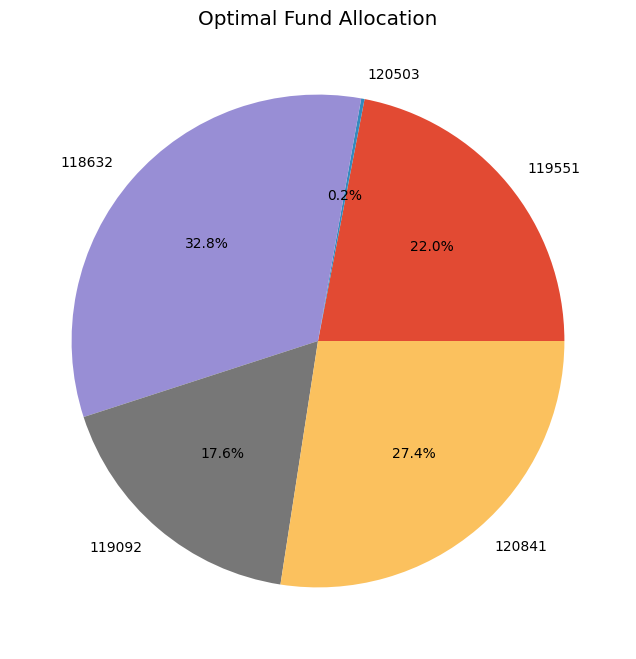

In [15]:
plt.figure(figsize=(8,8))

plt.pie(
    optimal_weights,
    labels=selected_funds,
    autopct="%1.1f%%"
)

plt.title(
    "Optimal Fund Allocation"
)

plt.show()

## Business Interpretation

The Efficient Frontier represents thousands of possible portfolio combinations generated from the five selected mutual funds.

Each point on the frontier represents a unique portfolio with a specific return-risk profile.

The portfolio with the highest Sharpe Ratio is considered optimal because it delivers the highest return per unit of risk.

Key Benefits:

- Diversification reduces overall portfolio risk.
- Combining multiple funds can improve risk-adjusted returns.
- Investors can select portfolios based on risk tolerance.
- The Efficient Frontier helps identify portfolios that are mathematically efficient.

# Conclusion

Markowitz Portfolio Optimisation demonstrates how portfolio construction can improve investment outcomes beyond individual fund selection.

The analysis identified an optimal allocation across five mutual funds that maximises risk-adjusted return while controlling portfolio volatility.

This approach provides a scientific framework for investment decision-making and complements other analytics performed in this project.